# Data prep illustration


In [1]:
import astropy.io.fits as pyfits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx

meta = MetaData()

pd.set_option('display.max_rows', 200)

# Custom functions

## Data from fits

In [2]:
def get_data_from_fits_file(file_path):
    """
    Get flux, sky, wave and ivar from a SDSS fits file.
    The fits file come from spec lite version of SDSS
    data reduction pipeline.
    """

    with pyfits.open(file_path, memmap=False) as hdul:
        # Get the data from HDU 1 (COADD)
        data = hdul[1].data
        specobjid = int(hdul[2].data["specobjid"].item())

    wavelength = 10**data['loglam']
    flux = data['flux']
    sky = data['SKY']
    ivar = data['ivar']
    
    return flux, sky, wavelength, ivar, specobjid

## SAS link

In [3]:
def get_sas_link(specobjid, df):

    row = df.loc[specobjid]
    plate = row['plate']
    sas_path = meta.get_file_location_sas(row)
    sdss_sas_link = (
        f"https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/{plate:04d}/"
    )
    print(sdss_sas_link)
    print(f"SAS path: {sas_path[-1]}\n\n")
# specobjid = 2670686319293786112 # SF

## OI interpolation

In [4]:
def OI_5577_interpolation(wave: np.array, spectrum: np.array) -> np.array:
    """
    Interpolate region of airglow radiation from the
    [OI]5577 region with the average flux of neighboring
    segments to that region

    INPUTS
    wave: wavelengths of the raw spectrum in observers
        frame
    spectrum: flux of spectrum in observers frame

    OUTPUT
    spectrum: flux with interpolation of the [OI]5577
        region caused by atmospheric airglow
    """

    OI_mask = np.logical_and(wave > 5565, wave < 5590)
    n_mask = OI_mask.sum()

    try:

        left_idx = np.argwhere(wave == wave[OI_mask][0])[0, 0]
        right_idx = np.argwhere(wave == wave[OI_mask][-1])[0, 0]

    except IndexError:

        return spectrum

    left_flux = spectrum[left_idx - n_mask : left_idx]
    right_flux = spectrum[right_idx : right_idx + n_mask]

    average_flux = (left_flux + right_flux) / 2.0

    spectrum[OI_mask] = average_flux

    return spectrum

### OI indicator

In [5]:
def add_oi_indicator(
    ax, wave, spec,
    indicator_starts,
    indicator_height,
    delta=1,
    indicator_color='blue',
    indicator_label_color='black',
    lw=1,
    fontsize=6,
):
    line_name = 'OI'
    line_wave = 557.7

    line_flux = np.max(
        spec[(wave > line_wave - delta) & (wave < line_wave + delta)]
    )

    # Plot vertical line indicator
    y_start_indicator = line_flux + indicator_starts
    y_end_indicator = y_start_indicator + indicator_height

    ax.plot(
        [line_wave, line_wave], 
        [y_start_indicator, y_end_indicator], 
        color=indicator_color, lw=lw
    )

    y_text_start = y_end_indicator + indicator_height/2

    ax.text(
        line_wave, 
        y_text_start, 
        line_name,
        ha='center', va='bottom', 
        fontsize=fontsize, rotation=90, 
        color=indicator_label_color
    )

    return ax

## Pixel noise masking

In [6]:
def remove_large_uncertainties(
    wave, flux, ivar
) -> np.array:
    """
    Set to NaN fluxes with large variance in their measurements

    INPUT
    flux: raw spectrum
    ivar: inverse of variance for fluxe measurements of spectrum

    OUTPUTS

    flux, variance: masked flux with large noise in its measurements
        and variance of flux measurements
    """

    n_nan_prior_OI_interp = np.isnan(flux).sum()
    flux = OI_5577_interpolation(wave, flux)
    n_nan_prior_masking = np.isnan(flux).sum()
    
    # Get variance of each flux
    ivar[ivar == 0] = np.nan
    variance = 1 / ivar
    variance[np.isnan(ivar)] = np.inf
    variance = np.nan_to_num(variance)

    # mask of: variance > flux [higly uncertain values]
    flux_no_nans = np.nan_to_num(flux)
    large_variance_mask = np.sqrt(variance) > flux_no_nans

    flux[large_variance_mask] = np.nan
    n_nan_after_masking = np.isnan(flux).sum()

    print(f"N of NaNs before OI interp: {n_nan_prior_OI_interp}")
    print(f"N of NaNs before masking: {n_nan_prior_masking}")
    print(f"N of NaNs after uncertainty masking: {n_nan_after_masking}")

    return flux, variance, large_variance_mask

## Dered spectrum

In [7]:
def dust_model() -> object:
    """Extinction function to dered spectra"""
    # dust model for dereden_spectrum
    wave = np.array([2600, 2700, 4110, 4670, 5470, 6000, 12200, 26500])

    extinction = np.array(
        [6.591, 6.265, 4.315, 3.806, 3.055, 2.688, 0.829, 0.265]
    )

    extinction = interp1d(wave, extinction, kind="cubic")

    return extinction

def dered_spectrum(
    flux: np.array, wave: np.array, ebv: float
) -> np.array:

    """
    Apply extinction function to spectrum for deredening.

    INPUTS
    flux: spectrum fluxes in observer frame
    wave: wavelengths of spectrum in observer frame
    ebv: E(B-v) from from Schlegel, Finkbeiner & Davis (1998)

    OUTPUT
    dered_flux: fluxes corrected by extinction
    """
    extinction_fn = dust_model()
    # extinction array for this spectrum
    extinction = extinction_fn(wave)
    extinction *= ebv

    dereded_flux = flux * 10 ** (extinction / 2.5)

    return dereded_flux

## OI + Noise + dered

In [8]:
def OI_noise_dered(wave, flux, ivar, ebv):

    flux, variance, large_variance_mask = remove_large_uncertainties(
        wave, flux, ivar
    )

    flux = dered_spectrum(flux, wave, ebv=ebv)

    return flux


## Common grid interpolation

In [9]:
lower, upper = 3500, 7500
number_waves = 4000
wave_grid = np.linspace(lower, upper, number_waves)
print(wave_grid.min(), wave_grid.max())

def common_grid_interp(wave_grid, wave, flux, z):

    rest_wave = wave / (1 + z)

    interp_flux = np.interp(
        wave_grid, rest_wave,
        flux,
        left=np.nan, right=np.nan
    )

    return interp_flux

3500.0 7500.0


# Directories

In [10]:
thesis_dir = "/home/elom/gdrive/career/portfolio/phd/thesis"
ch_3_dir = f"{thesis_dir}/chapters/03_figures"

data_dir = "/home/elom/phd/code/spectra"
fits_files_dir = f"{data_dir}/fits_files_illustrations"
bin_id = "bin_03"

# Data ingestion

In [11]:
wave = np.load(f"{data_dir}/wave_spectra_imputed.npy")

spectra = np.load(
    f"{data_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

idx_id_bin_03 = np.load(
    f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)

# Metadata
drop_meta_data_df = pd.read_csv(
    f"{data_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

final_meta_data_df = pd.read_csv(
    f"{data_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

bin_03_df = final_meta_data_df.loc[idx_id_bin_03[:, 1]].copy()

# Sky removal

## Data

In [12]:
print("Evolved galaxy")
# -------------------------------------------------
file_location = f'{fits_files_dir}/spec-1587-52964-0435.fits'
(
    evolved_raw_flux, evolved_sky,
    evolved_raw_wave, evolved_ivar, evolved_specobjid
) = get_data_from_fits_file(file_location)
# -------------------------------------------------
print(drop_meta_data_df.loc[evolved_specobjid, 'subClass'])
# -------------------------------------------------
evolved_flux_OI_interp = OI_5577_interpolation(
    evolved_raw_wave.copy(), evolved_raw_flux.copy()
)
# -------------------------------------------------
# mask for visualization
evolved_oi_mask = evolved_raw_wave < 7500

evolved_raw_wave = evolved_raw_wave[evolved_oi_mask]
evolved_raw_wave_nm = evolved_raw_wave * 0.1
evolved_raw_flux = evolved_raw_flux[evolved_oi_mask]
evolved_flux_OI_interp = evolved_flux_OI_interp[evolved_oi_mask]
evolved_sky = evolved_sky[evolved_oi_mask]
evolved_ivar = evolved_ivar[evolved_oi_mask]

# -------------------------------------------------
evolved_median_flux_sky = np.nanmedian(evolved_raw_flux + evolved_sky)
evolved_median_sky = np.nanmedian(evolved_sky)
evolved_median_flux = np.nanmedian(evolved_raw_flux)
evolved_median_flux_OI_interp = np.nanmedian(evolved_flux_OI_interp)

print(f"Median raw flux + sky: {evolved_median_flux_sky:.2f}")
print(f"Median sky: {evolved_median_sky:.2f}")
print(f"Median raw flux: {evolved_median_flux:.2f}")
print(f"Median raw flux (OI interpolated): {evolved_median_flux_OI_interp:.2f}")
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
print("Star-forming galaxy")
# -------------------------------------------------
file_location = f'{fits_files_dir}/spec-2636-54082-0164.fits'
(
    sf_raw_flux, sf_sky,
    sf_raw_wave, sf_ivar, sf_specobjid
) = get_data_from_fits_file(file_location)
# -------------------------------------------------
print(drop_meta_data_df.loc[sf_specobjid, 'subClass'])
# -------------------------------------------------
sf_flux_OI_interp = OI_5577_interpolation(
    sf_raw_wave.copy(), sf_raw_flux.copy()
)
# -------------------------------------------------
# mask for visualization
sf_oi_mask = sf_raw_wave < 7500

sf_raw_wave = sf_raw_wave[sf_oi_mask]
sf_raw_wave_nm = sf_raw_wave * 0.1
sf_raw_flux = sf_raw_flux[sf_oi_mask]
sf_flux_OI_interp = sf_flux_OI_interp[sf_oi_mask]
sf_sky = sf_sky[sf_oi_mask]
sf_ivar = sf_ivar[sf_oi_mask]

# -------------------------------------------------
sf_median_flux_sky = np.nanmedian(sf_raw_flux + sf_sky)
sf_median_sky = np.nanmedian(sf_sky)
sf_median_flux = np.nanmedian(sf_raw_flux)
sf_median_flux_OI_interp = np.nanmedian(sf_flux_OI_interp)

print(f"Median raw flux + sky: {sf_median_flux_sky:.2f}")
print(f"Median sky: {sf_median_sky:.2f}")
print(f"Median raw flux: {sf_median_flux:.2f}")
print(f"Median raw flux (OI interpolated): {sf_median_flux_OI_interp:.2f}")

Evolved galaxy
nan
Median raw flux + sky: 173.06
Median sky: 6.89
Median raw flux: 165.63
Median raw flux (OI interpolated): 165.63
Star-forming galaxy
STARFORMING
Median raw flux + sky: 50.33
Median sky: 6.85
Median raw flux: 43.43
Median raw flux (OI interpolated): 43.43


## Evolved + SF 3X2 grid OI interp

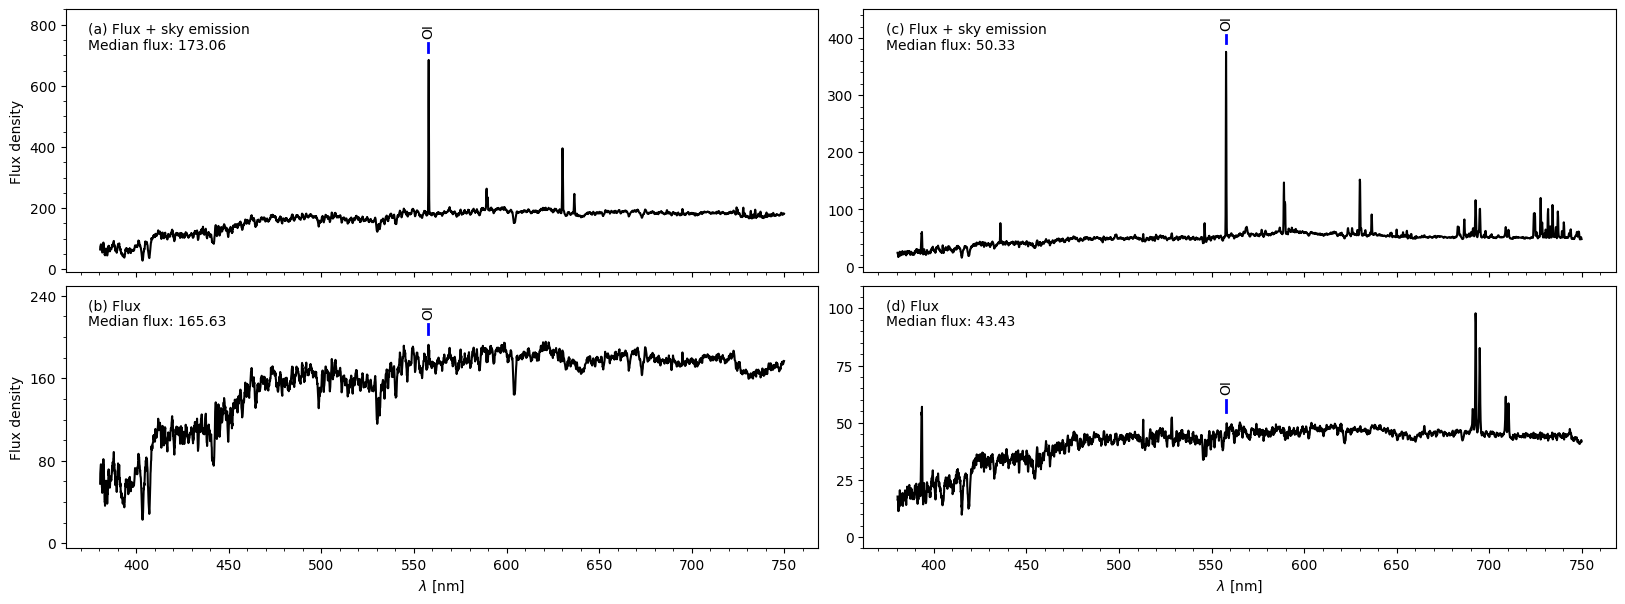

In [13]:
# Figure
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 7),
    sharex=True,
)
# -------------------------------------------------
# Evolved
# Flux + sky
axs[0, 0].plot( evolved_raw_wave_nm, evolved_raw_flux + evolved_sky, color='black')

axs[0, 0].text(
    0.03, 0.95,
    f'(a) Flux + sky emission\nMedian flux: {evolved_median_flux_sky:.2f}', 
    transform=axs[0, 0].transAxes, 
    verticalalignment='top',
)
# -------------------------------------------------
# Flux
axs[1, 0].plot(evolved_raw_wave_nm, evolved_raw_flux, color='black')

axs[1, 0].text(
    0.03, 0.95,
    f'(b) Flux\nMedian flux: {evolved_median_flux:.2f}', 
    transform=axs[1, 0].transAxes, 
    verticalalignment='top', 
)
# -------------------------------------------------
# -------------------------------------------------
# Starforming
# Flux + sky
axs[0, 1].plot(sf_raw_wave_nm, sf_raw_flux + sf_sky, color='black')

axs[0, 1].text(
    0.03, 0.95,
    f'(c) Flux + sky emission\nMedian flux: {sf_median_flux_sky:.2f}', 
    transform=axs[0, 1].transAxes, 
    verticalalignment='top', 
)
# Flux
axs[1, 1].plot(sf_raw_wave_nm, sf_raw_flux, color='black')

axs[1, 1].text(
    0.03, 0.95,
    f'(d) Flux\nMedian flux: {sf_median_flux:.2f}', 
    transform=axs[1, 1].transAxes, 
    verticalalignment='top', 
)    
# -------------------------------------------------
# Add OI indicators & set y-limits
# -------------------------------------------------
axs[0, 0].set_ylim(-10, 850) 
ticks = [0, 200, 400, 600, 800]
axs[0, 0].set_yticks(ticks)
add_oi_indicator(
    axs[0, 0], evolved_raw_wave_nm,
    evolved_raw_flux + evolved_sky,
    indicator_starts=25, indicator_height=30,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[1, 0].set_ylim(-5, 250) 
ticks = [0, 80, 160, 240]
axs[1, 0].set_yticks(ticks)
add_oi_indicator(
    axs[1, 0], evolved_raw_wave_nm,
    evolved_raw_flux,
    indicator_starts=10, indicator_height=10,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[0, 1].set_ylim(-10, 450) 
ticks = [0, 100, 200, 300, 400]
axs[0, 1].set_yticks(ticks)

add_oi_indicator(
    axs[0, 1], sf_raw_wave_nm,
    sf_raw_flux + sf_sky,
    indicator_starts=15, indicator_height=15,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[1, 1].set_ylim(-5, 110) 
ticks = [0, 25, 50, 75, 100]
axs[1, 1].set_yticks(ticks)

add_oi_indicator(
    axs[1, 1], sf_raw_wave_nm,
    sf_raw_flux,
    indicator_starts=5, indicator_height=5,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")


y_label = 'Flux density'
axs[0, 0].set_ylabel(y_label)
axs[1, 0].set_ylabel(y_label)

for ax in axs.flatten():
    ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)
# -------------------------------------------------
fig.savefig(
    f"{ch_3_dir}/sky_removal.pdf",
    bbox_inches='tight'
)

# [OI] 557.7 nm interpolation

## Data

In [14]:
delta_oi = 15
oi_lambda = 557.7
upper_wave = oi_lambda + delta_oi
lower_wave = oi_lambda - delta_oi
# -------------------------------------------------
# evolved mask
evolved_oi_mask = (
    (evolved_raw_wave_nm > lower_wave)
    &
    (evolved_raw_wave_nm < upper_wave)
)
# star forming mask
sf_oi_mask = (
    (sf_raw_wave_nm > lower_wave)
    &
    (sf_raw_wave_nm < upper_wave)
)

## OI region 2X2 prior/after interpolation

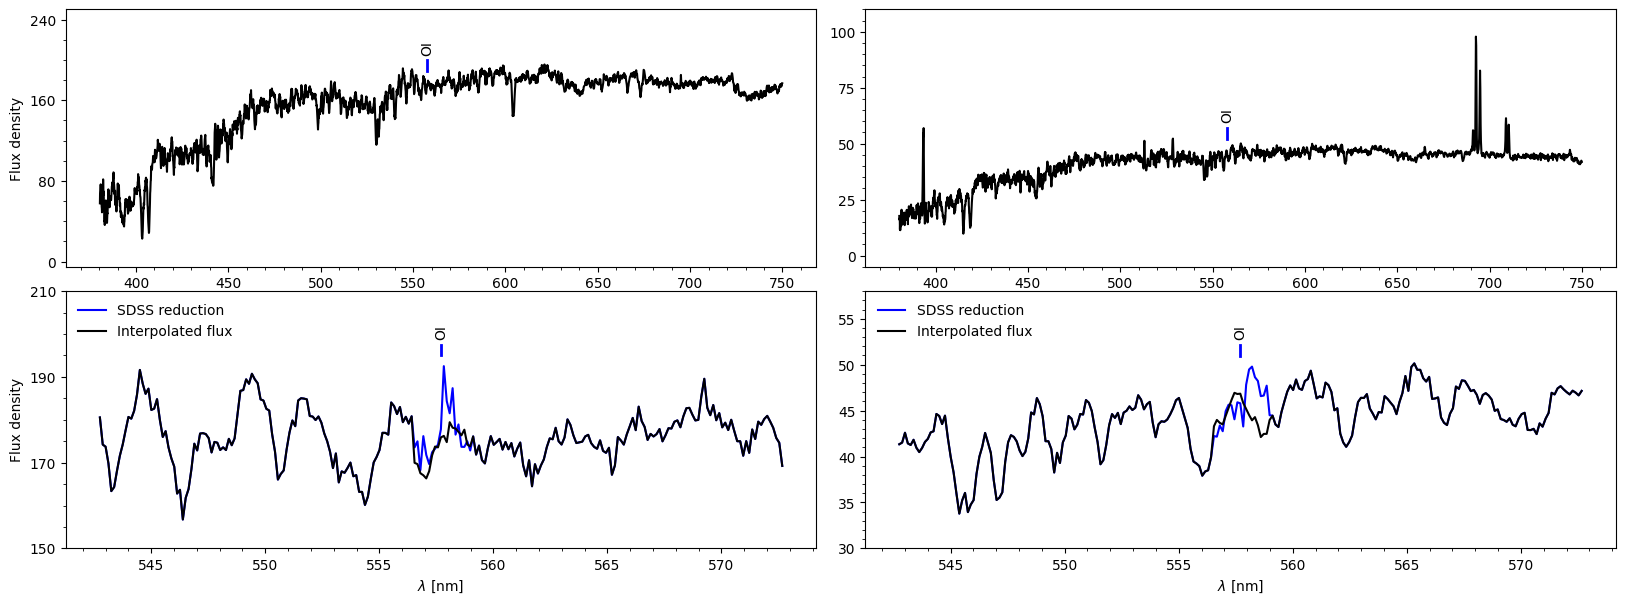

In [21]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 7),
    sharex=False,
)
# -------------------------------------------------
axs[0, 0].plot(evolved_raw_wave_nm, evolved_flux_OI_interp, color='black')

axs[1, 0].plot(
    evolved_raw_wave_nm[evolved_oi_mask],
    evolved_raw_flux[evolved_oi_mask],
    color='blue',
    label='SDSS reduction'
)
axs[1, 0].plot(
    evolved_raw_wave_nm[evolved_oi_mask],
    evolved_flux_OI_interp[evolved_oi_mask],
    color='black',
    label='Interpolated flux'
)
# -------------------------------------------------
axs[0, 1].plot(sf_raw_wave_nm, sf_flux_OI_interp, color='black')
axs[1, 1].plot(
    sf_raw_wave_nm[sf_oi_mask],
    sf_raw_flux[sf_oi_mask],
    color='blue',
    label='SDSS reduction'
)
axs[1, 1].plot(
    sf_raw_wave_nm[sf_oi_mask],
    sf_flux_OI_interp[sf_oi_mask],
    color='black',
    label='Interpolated flux'
)
# -------------------------------------------------
axs[1, 0].legend(loc='upper left', frameon=False)
axs[1, 1].legend(loc='upper left', frameon=False)
# -------------------------------------------------
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")

y_label = 'Flux density'
axs[0, 0].set_ylabel(y_label)
axs[1, 0].set_ylabel(y_label)

for ax in axs.flatten():
    ax.minorticks_on()
# -------------------------------------------------
# Add OI indicators & set y-limits
# -------------------------------------------------
axs[1, 0].set_ylim(150, 210) 
ticks = [150, 170, 190, 210]
axs[1, 0].set_yticks(ticks)
add_oi_indicator(
    axs[1, 0], evolved_raw_wave_nm[evolved_oi_mask],
    evolved_raw_flux[evolved_oi_mask],
    indicator_starts=2.5, indicator_height=2.5,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[1, 1].set_ylim(30, 58)
ticks = [30, 35, 40, 45, 50, 55]
axs[1, 1].set_yticks(ticks)
add_oi_indicator(
    axs[1, 1], sf_raw_wave_nm[sf_oi_mask],
    sf_raw_flux[sf_oi_mask],
    indicator_starts=1.2, indicator_height=1.2,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[0, 0].set_ylim(-5, 250) 
ticks = [0, 80, 160, 240]
axs[0, 0].set_yticks(ticks)
add_oi_indicator(
    axs[0, 0], evolved_raw_wave_nm,
    evolved_flux_OI_interp,
    indicator_starts=10, indicator_height=10,
    delta=1, lw=2, fontsize=10
)
# -------------------------------------------------
axs[0, 1].set_ylim(-5, 110) 
ticks = [0, 25, 50, 75, 100]
axs[0, 1].set_yticks(ticks)

add_oi_indicator(
    axs[0, 1], sf_raw_wave_nm,
    sf_flux_OI_interp,
    indicator_starts=5, indicator_height=5,
    delta=1, lw=2, fontsize=10
)
# adjust vertical space
plt.subplots_adjust(
    hspace=0.095,
    wspace=0.065
)
# -------------------------------------------------
fig.savefig(
    f"{ch_3_dir}/oi_interpolation_region.pdf",
    bbox_inches='tight'
)

# Pixel-level noise masking

## Data

In [22]:
count_std_larger_than_flux = np.load(
    f"{data_dir}/count_std_larger_than_flux.npy"
).astype(int)
mapping_dict = dict(count_std_larger_than_flux)

In [23]:
bin_03_df['count_std_gt_flux'] = bin_03_df.index.map(mapping_dict)
bin_03_df.sort_values(by='count_std_gt_flux', ascending=False, inplace=True)


In [24]:
cols = [
    'count_std_gt_flux', 'snMedian', 'ebv', 'z', 'subClass',
    # 'mjd', 'plate', 'fiberid', 'run2d', 'ra', 'dec'
]
bin_03_df[cols].head(1000).to_clipboard()

In [25]:
specobjid = 2670686319293786112 # SF
row = bin_03_df.loc[specobjid]
print(
    # f"SpecObjID: {specobjid},"
    f"count_std_gt_flux: {row['count_std_gt_flux']},"
    f"S/N: {row['snMedian']},"
    f"z: {row['z']},"
    f"subClass: {row['subClass']},"
    # f"ebv: {row['ebv']}"        
)
plate = row['plate']
sas_path = meta.get_file_location_sas(row)
sdss_sas_link = (
    f"https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/{plate:04d}/"
)
print(sdss_sas_link)
print(f"SAS path: {sas_path[-1]}\n\n")


count_std_gt_flux: 261,S/N: 19.22747,z: 0.05520408,subClass: STARFORMING,
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/2372/
SAS path: spec-2372-53768-0188




N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 261


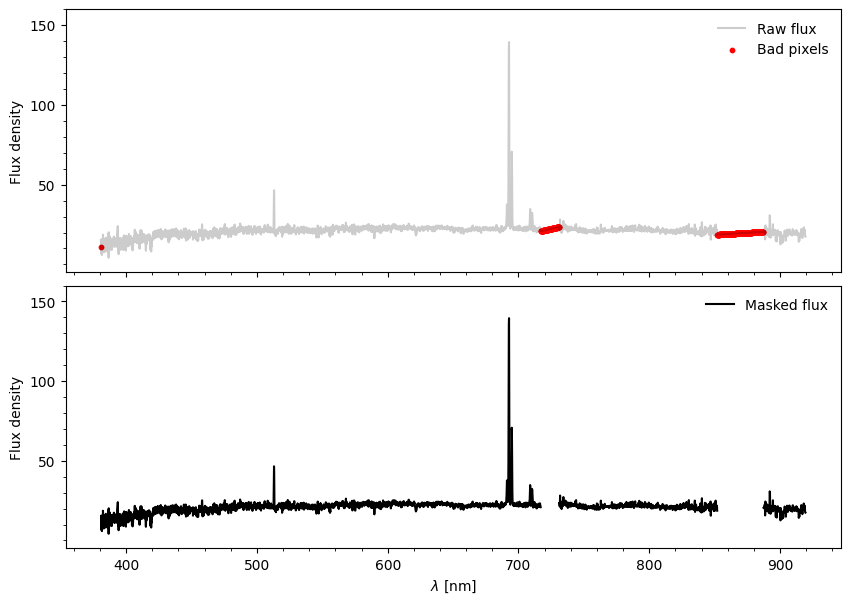

In [26]:
# Get data
fname = "spec-2372-53768-0188.fits"
file_location = f'{fits_files_dir}/pixel_level_noise/{fname}'
(
    raw_flux, sky,
    raw_wave, ivar, specobjid
) = get_data_from_fits_file(file_location)

flux, variance, large_variance_mask = remove_large_uncertainties(
    wave=raw_wave, flux=raw_flux.copy(), ivar=ivar
)
# ---------------------------------------------------------------
raw_wave_nm = raw_wave * 0.1
# ---------------------------------------------------------------
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
)
# ---------------------------------------------------------------
axs[0].plot(raw_wave_nm, raw_flux, color="black", alpha=0.2, label='Raw flux')

axs[0].scatter(
    raw_wave_nm[large_variance_mask],
    raw_flux[large_variance_mask],
    color="red",
    marker="o",
    s=10,
    alpha=1,
    label="Bad pixels"
)
# ---------------------------------------------------------------
axs[1].plot(raw_wave_nm, flux, color="black", label='Masked flux')
# ---------------------------------------------------------------
# Add legends to both panels
axs[0].legend(loc="upper right", frameon=False)
axs[1].legend(loc="upper right", frameon=False)
# ---------------------------------------------------------------
ticks = [50, 100, 150]
for ax in axs.flatten():
    ax.set_ylim(-5, 160)
    ax.set_yticks(ticks)
    ax.minorticks_on()
# ---------------------------------------------------------------

y_label = 'Flux density'
axs[0].set_ylabel(y_label)
axs[1].set_ylabel(y_label)
axs[-1].set_xlabel(r"$\lambda$ [nm]")
# ---------------------------------------------------------------
# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
)
fig.savefig(
    f"{ch_3_dir}/noise_masking.pdf",
    bbox_inches='tight'
)


# Galactic extinction correction

In [27]:
# Find large 'ebv'
sf_mask = drop_meta_data_df['subClass'] == 'STARFORMING'
cols = [
    'mjd', 'plate', 'fiberid', 'run2d',
    'snMedian', 'z', 'ra', 'dec', 'ebv', 'subClass'
]

ebv_sf_03_df = bin_03_df.loc[sf_mask, cols].sort_values(by='ebv', ascending=False).copy()

In [ ]:
# ebv_sf_03_df[ ['snMedian', 'z', 'ra', 'dec', 'ebv', 'subClass']].iloc[:100].to_clipboard()

In [ ]:
# ebv_sf_03_df[
#     ['snMedian', 'z', 'ra', 'dec', 'ebv', 'subClass']
# ].sort_values(by='ebv', ascending=True).iloc[38_200:38_230].to_clipboard()

In [28]:
# high ebv
specobjid = 1408652565792450560
get_sas_link(specobjid, bin_03_df)
ebv_sf_03_df.loc[specobjid]

https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1251/
SAS path: spec-1251-52964-0552




mjd               52964
plate              1251
fiberid             552
run2d                26
snMedian       24.92456
z              0.025235
ra            65.583319
dec           29.320077
ebv             0.48334
subClass    STARFORMING
Name: 1408652565792450560, dtype: object

In [29]:
# low ebv
specobjid = 466257282963892224
get_sas_link(specobjid, bin_03_df)
ebv_sf_03_df.loc[specobjid]

https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/0414/
SAS path: spec-0414-51869-0490




mjd               51869
plate               414
fiberid             490
run2d                26
snMedian       40.02825
z              0.020425
ra            51.708886
dec            0.198571
ebv            0.106394
subClass    STARFORMING
Name: 466257282963892224, dtype: object

## Data

In [30]:
high_ebv_specobjid = 1408652565792450560
fname_high_ebv = 'spec-1251-52964-0552.fits'

(
    high_ebv_raw_flux, high_ebv_sky,
    high_ebv_raw_wave, high_ebv_ivar, _high_ebv_specobjid
) = get_data_from_fits_file(f'{fits_files_dir}/{fname_high_ebv}')

are_same = high_ebv_specobjid == _high_ebv_specobjid

print(are_same)
high_ebv_raw_wave_nm = high_ebv_raw_wave*0.1

(
    high_ebv_flux_noise_masking,
    high_ebv_variance,
    high_ebv_large_variance_mask
) = remove_large_uncertainties(
    high_ebv_raw_wave, high_ebv_raw_flux, high_ebv_ivar
)

high_ebv = ebv_sf_03_df.loc[high_ebv_specobjid, 'ebv']
print(f"High: E(B-V): {high_ebv:.4f}")

high_ebv_dered_flux = dered_spectrum(
    high_ebv_flux_noise_masking,
    high_ebv_raw_wave,
    ebv=high_ebv
)
z_hig_ebv = bin_03_df.loc[high_ebv_specobjid, 'z']
# # --------------------------------------
low_ebv_specobjid = 466257282963892224
fname_low_ebv = 'spec-0414-51869-0490.fits'

(
    low_ebv_raw_flux, low_ebv_sky,
    low_ebv_raw_wave, low_ebv_ivar, _low_ebv_specobjid
) = get_data_from_fits_file(f'{fits_files_dir}/{fname_low_ebv}')

are_same = low_ebv_specobjid == _low_ebv_specobjid

print(are_same)
low_ebv_raw_wave_nm = low_ebv_raw_wave*0.1
(
    low_ebv_flux_noise_masking,
    low_ebv_variance,
    low_ebv_large_variance_mask
) = remove_large_uncertainties(
    low_ebv_raw_wave, low_ebv_raw_flux, low_ebv_ivar
)

low_ebv = ebv_sf_03_df.loc[low_ebv_specobjid, 'ebv']
print(f"Low: E(B-V): {low_ebv:.4f}")

low_ebv_dered_flux = dered_spectrum(
    low_ebv_flux_noise_masking,
    low_ebv_raw_wave,
    ebv=low_ebv
)
z_low_ebv = bin_03_df.loc[high_ebv_specobjid, 'z']


True
N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 3
High: E(B-V): 0.4833
True
N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 0
Low: E(B-V): 0.1064


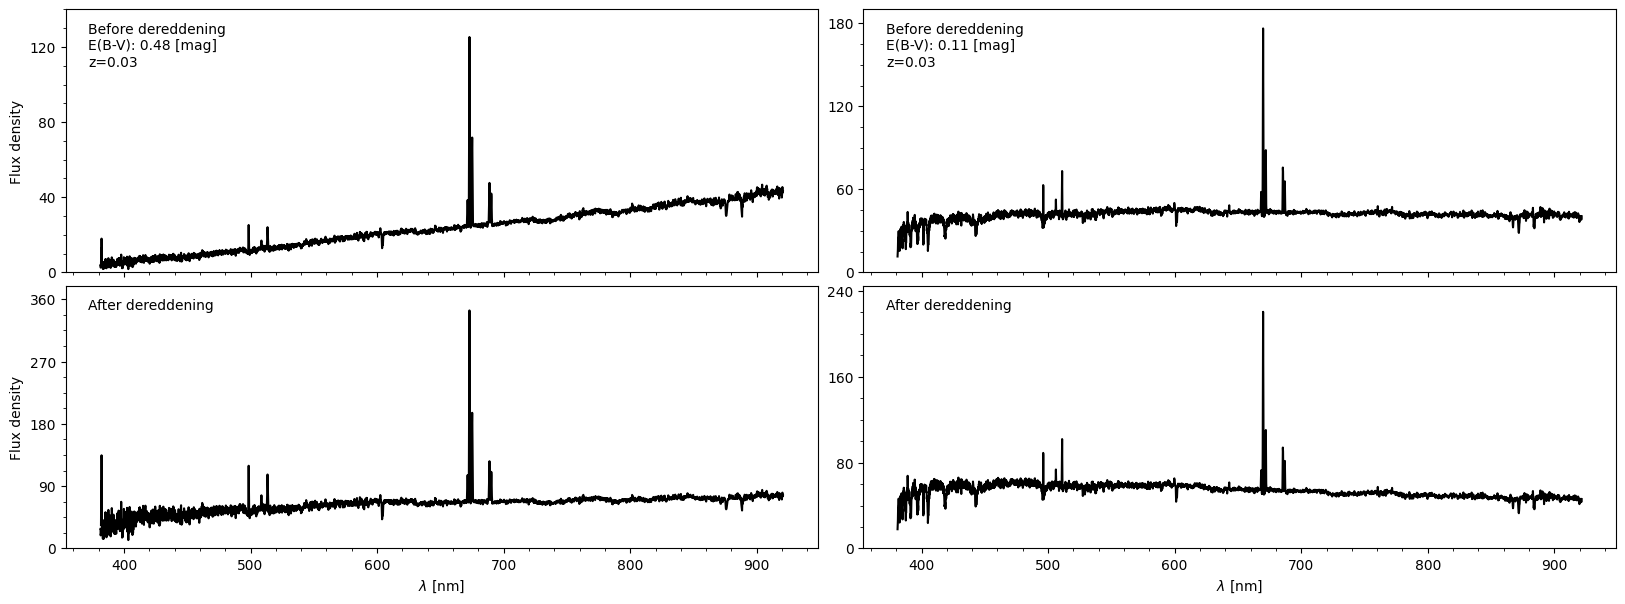

In [31]:
# -------------------------------------------------
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 7),
    sharex=True,
)
# -------------------------------------------------
y_label = 'Flux density'
# -------------------------------------------------
# ------------------- High EBV --------------------
axs[0, 0].plot(high_ebv_raw_wave_nm, high_ebv_flux_noise_masking, color='black')
    
axs[0, 0].text(
    0.03, 0.95,
    f'Before dereddening\nE(B-V): '
    f'{high_ebv:.2f} [mag]\nz={z_hig_ebv:.2f}', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[0, 0].set_ylim(0, 140) 
ticks = [0, 40, 80, 120]
axs[0, 0].set_yticks(ticks)
axs[0, 0].set_ylabel(y_label)
# -------------------------------------------------
axs[1, 0].plot(high_ebv_raw_wave_nm, high_ebv_dered_flux, color='black')
axs[1, 0].text(
    0.03, 0.95,
    f'After dereddening', 
    transform=axs[1,0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[1, 0].set_ylim(0, 380) 
ticks = [0, 90, 180, 270, 360]
axs[1, 0].set_yticks(ticks)
axs[1, 0].set_ylabel(y_label)
# ------------------- Low EBV --------------------
axs[0, 1].plot(low_ebv_raw_wave_nm, low_ebv_flux_noise_masking, color='black')
    
axs[0, 1].text(
    0.03, 0.95,
    f'Before dereddening\nE(B-V): '
    f'{low_ebv:.2f} [mag]\nz={z_low_ebv:.2f}', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[0, 1].set_ylim(0, 190) 
ticks = [0, 60, 120, 180]
axs[0, 1].set_yticks(ticks)
# -------------------------------------------------
axs[1, 1].plot(low_ebv_raw_wave_nm, low_ebv_dered_flux, color='black')
axs[1, 1].text(
    0.03, 0.95,
    f'After dereddening', 
    transform=axs[1,1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[1, 1].set_ylim(0, 245) 
ticks = [0, 80, 160, 240]
axs[1, 1].set_yticks(ticks)
# -------------------------------------------------
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)
fig.savefig(
    f"{ch_3_dir}/gal_ext_correction.pdf",
    bbox_inches='tight'
)


# Rest frame

In [32]:
# ebv_df.sort_values(by='z', ascending=False).head(50)

In [32]:
# get sas link
specobjid = 622684254672807936
# row = bin_03_df.loc[specobjid]
get_sas_link(specobjid, df=final_meta_data_df)
final_meta_data_df.loc[specobjid]


https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/0553/
SAS path: spec-0553-51999-0224




mjd                     51999
plate                     553
fiberid                   224
run2d                      26
ra                  137.41097
dec                 51.557596
z                    0.288776
zErr                 0.000008
zWarning                    0
class                  GALAXY
subClass          STARFORMING
z_noqso                     0
zErr_noqso                  0
zWarning_noqso              0
targetType            SCIENCE
programname            legacy
instrument               SDSS
snMedian             15.54379
ABSSB             STARFORMING
BROAD             STARFORMING
ebv                  0.014155
indexArray           263763.0
Name: 622684254672807936, dtype: object

## Data

In [33]:
# Spec 1
spec_1_location = f'{fits_files_dir}/spec-1254-52972-0209.fits'
(
    raw_flux_1, sky_1,
    raw_wave_1, ivar_1, specobjid_1
) = get_data_from_fits_file(spec_1_location)

ebv_1 = drop_meta_data_df.loc[specobjid_1, 'ebv']

dered_flux_1 = OI_noise_dered(
    raw_wave_1, raw_flux_1,
    ivar_1, ebv_1
)
print(dered_flux_1.shape)
# convert to nanometers
z_1 = drop_meta_data_df.loc[specobjid_1, 'z']
rest_wave_1 = raw_wave_1 / (1 + z_1)
print("-"*50)
# -------------------------------------------------
# Spec 2
spec_2_location = f'{fits_files_dir}/spec-0553-51999-0224.fits'
(
    raw_flux_2, sky_2,
    raw_wave_2, ivar_2, specobjid_2
) = get_data_from_fits_file(spec_2_location)

ebv_2 = drop_meta_data_df.loc[specobjid_2, 'ebv']

dered_flux_2 = OI_noise_dered(
    raw_wave_2, raw_flux_2,
    ivar_2, ebv_2
)
z_2 = drop_meta_data_df.loc[specobjid_2, 'z']
rest_wave_2 = raw_wave_2 / (1 + z_2)
print("-"*50)
# print some metadata
print(f"z_1: {z_1:.4f}")
print(f"z_2: {z_2:.4f}")
print("-"*50)
print(f"E(B-V)_1: {ebv_1:.4f}")
print(f"E(B-V)_2: {ebv_2:.4f}")

N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 0
(3833,)
--------------------------------------------------
N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 6
--------------------------------------------------
z_1: 0.0219
z_2: 0.2888
--------------------------------------------------
E(B-V)_1: 0.4226
E(B-V)_2: 0.0142


In [ ]:
# add rest frame in black and observed frame in blue
# play with colors so it looks good
# add emission line indicators for rest frame only

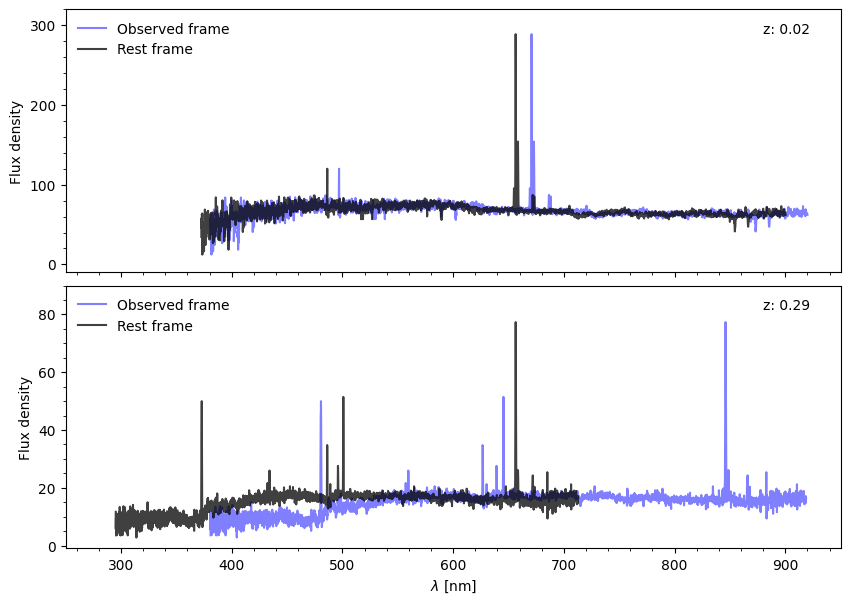

In [34]:
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
)
# -------------------------------------------------
y_label = 'Flux density'
# convert to nm
raw_wave_1_nm = raw_wave_1*0.1
rest_wave_1_nm = rest_wave_1*0.1
#
raw_wave_2_nm = raw_wave_2*0.1
rest_wave_2_nm = rest_wave_2*0.1
# -------------------------------------------------
# Spec 1
# Observed frame
axs[0].plot(
    raw_wave_1_nm, dered_flux_1,
    color='blue', alpha=0.5,
    label='Observed frame'
)
axs[0].plot(
    rest_wave_1_nm, dered_flux_1,
    color='black',
    alpha=0.75,
    label='Rest frame'
)
axs[0].text(
    0.9, 0.95,
    f'z: {z_1:.2f}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[0].set_xlim(250, 950)
axs[0].set_ylim(-10, 320)

ticks = [0, 100, 200, 300]
axs[0].set_yticks(ticks)
axs[0].set_ylabel(y_label)
# -------------------------------------------------
# Spec 2
axs[1].plot(
    raw_wave_2_nm, dered_flux_2,
    color='blue', alpha=0.5,
    label='Observed frame'
)
axs[1].plot(
    rest_wave_2_nm, dered_flux_2,
    color='black',
    alpha=0.75,
    label='Rest frame'
)

axs[1].text(
    0.9, 0.95,
    f'z: {z_2:.2f}', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[1].set_ylim(-1, 90)
ticks = [0, 20, 40, 60, 80]
axs[1].set_yticks(ticks)

axs[1].set_ylabel(y_label)
axs[1].set_xlim(250, 950)

# -------------------------------------------------
axs[0].legend(loc='upper left', frameon=False)
axs[1].legend(loc='upper left', frameon=False)
axs[-1].set_xlabel(r"$\lambda$ [nm]")
  
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    # wspace=0.1
)

fig.savefig(
    f"{ch_3_dir}/rest_frame.pdf",
    bbox_inches='tight'
)

# Interpolation to a common grid

## Data

In [38]:
# Spec 1
spec_1_location = f'{fits_files_dir}/spec-1254-52972-0209.fits'
(
    raw_flux_1, sky_1,
    raw_wave_1, ivar_1, specobjid_1
) = get_data_from_fits_file(spec_1_location)


raw_flux_OI_interpolated_1 = OI_5577_interpolation(
    raw_wave_1.copy(), raw_flux_1.copy()
)

flux_noise_masking_1, variance_1, ivar_1 = remove_large_uncertainties(
    raw_wave_1, raw_flux_OI_interpolated_1.copy(), ivar_1
)

ebv_1 = final_meta_data_df.loc[specobjid_1, 'ebv']

dered_flux_1 = dered_spectrum(flux_noise_masking_1.copy(), raw_wave_1, ebv=ebv_1)

z_1 = final_meta_data_df.loc[specobjid_1, 'z']
rest_wave_1 = raw_wave_1 / (1 + z_1)

interp_flux_1 = np.interp(
    wave_grid, rest_wave_1,
    dered_flux_1.copy(),
    left=np.nan, right=np.nan
)

N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 0


In [39]:
# -------------------------------------------------
# Spec 2
spec_2_location = f'{fits_files_dir}/spec-0553-51999-0224.fits'
(
    raw_flux_2, sky_2,
    raw_wave_2, ivar_2, specobjid_2
) = get_data_from_fits_file(spec_2_location)


raw_flux_OI_interpolated_2 = OI_5577_interpolation(
    raw_wave_2.copy(), raw_flux_2.copy()
)

flux_noise_masking_2, variance_2, ivar_2 = remove_large_uncertainties(
    raw_wave_2, raw_flux_OI_interpolated_2.copy(), ivar_2
)

ebv_2 = final_meta_data_df.loc[specobjid_2, 'ebv']

dered_flux_2 = dered_spectrum(raw_flux_OI_interpolated_2, raw_wave_2, ebv=ebv_2)

z_2 = final_meta_data_df.loc[specobjid_2, 'z']
rest_wave_2 = raw_wave_2 / (1 + z_2) 

interp_flux_2 = np.interp(
    wave_grid, rest_wave_2,
    dered_flux_2,
    left=np.nan, right=np.nan
)

N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 6


In [40]:
a, b = np.nanmin(rest_wave_1), np.nanmax(rest_wave_1)
print(f"spec1: {a:.0f}, {b:.0f}")
c, d = np.nanmin(rest_wave_2), np.nanmax(rest_wave_2)
print(f"spec2: {c:.0f}, {d:.0f}")

spec1: 3726, 9003
spec2: 2951, 7129


## Figure

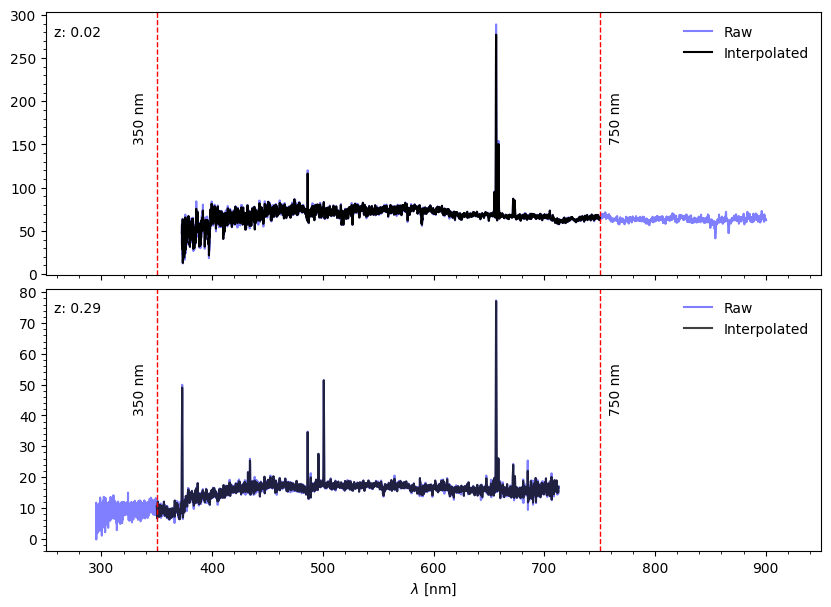

In [41]:
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
)
# -------------------------------------------------
y_label = 'Flux density'
# convert waves to nm
wave_grid_nm = wave_grid*0.1
rest_wave_1_nm = rest_wave_1*0.1 
rest_wave_2_nm = rest_wave_2*0.1 
# -------------------------------------------------
# Spec 1
# Observed frame

axs[0].plot(
    rest_wave_1_nm, dered_flux_1,
    color='blue', alpha=0.5,
    label='Raw'
)
axs[0].plot(
    wave_grid_nm, interp_flux_1,
    color='black',
    label='Interpolated'
)


# axs[0].set_xlim(350, 902)

# axs[0].set_ylim(-10, 320) 
# ticks = [0, 100, 200, 300]
# axs[0].set_yticks(ticks)
# axs[0].set_ylabel(y_label)

# -------------------------------------------------

# Spec 2

axs[1].plot(
    rest_wave_2_nm, dered_flux_2,
    color='blue', alpha=0.5,
    label='Raw'
)
axs[1].plot(
    wave_grid_nm, interp_flux_2,
    alpha=0.75,
    color='black',
    label='Interpolated'
)


# axs[1].set_ylim(-1, 90) 
# ticks = [0, 20, 40, 60, 80]
# axs[1].set_yticks(ticks)

# axs[1].set_ylabel(y_label)
axs[1].set_xlim(250, 950)

# -------------------------------------------------
axs[0].text(
    0.01, 0.95,
    f'z: {z_1:.2f}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[1].text(
    0.01, 0.95,
    f'z: {z_2:.2f}', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
# -------------------------------------------------
for ax in axs.flatten():

    ax.axvline(
        x=350, color='red', linestyle='--',
        linewidth=1,
        # label='350, 750 nm'
    )
    ax.axvline(
        x=750, color='red', linestyle='--',
        linewidth=1
    )

axs[0].text(
    335, 150, 
    '350 nm',
    ha='center', va='bottom',rotation=90, 
    fontsize=10,  
    color='black'
)
axs[0].text(
    765, 150, 
    '750 nm',
    ha='center', va='bottom',rotation=90, 
    fontsize=10,  
    color='black'
)

axs[1].text(
    335, 40, 
    '350 nm',
    ha='center', va='bottom',rotation=90, 
    fontsize=10,  
    color='black'
)
axs[1].text(
    765, 40, 
    '750 nm',
    ha='center', va='bottom',rotation=90, 
    fontsize=10,  
    color='black'
)
# -------------------------------------------------

axs[0].legend(loc='upper right', frameon=False)
axs[1].legend(loc='upper right', frameon=False)

axs[-1].set_xlabel(r"$\lambda$ [nm]")
  
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    # wspace=0.1
)
fig.savefig(
    f"{ch_3_dir}/common_grid_interpolation.pdf",
    bbox_inches='tight'
)

# Median normalization

## Data

In [43]:
bin_03_df.subClass.value_counts(dropna=False)

subClass
NaN                      116821
STARFORMING               38464
STARBURST                 10050
BROADLINE                  8203
AGN                        6444
AGN BROADLINE              1249
STARFORMING BROADLINE       604
STARBURST BROADLINE          15
Name: count, dtype: int64

In [44]:
sf_mask = bin_03_df.subClass == 'STARFORMING'
sf_03_df = bin_03_df.loc[sf_mask].copy()
sf_03_df[['z', 'snMedian']].describe()

,z,snMedian
count,38464.000000,38464.000000
mean,0.066129,22.844350
std,0.032607,5.339320
min,0.010044,17.543710
25%,0.040917,19.045522
50%,0.062864,21.159295
75%,0.084356,24.925280
max,0.271920,89.710140


S/N: 20.63169,z: 0.01926105,subClass: STARFORMING,ebv: 0.0143994819402391
sdss link: https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1332
fname:spec-1332-52781-0597.fits
N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 842
29.592813175123567


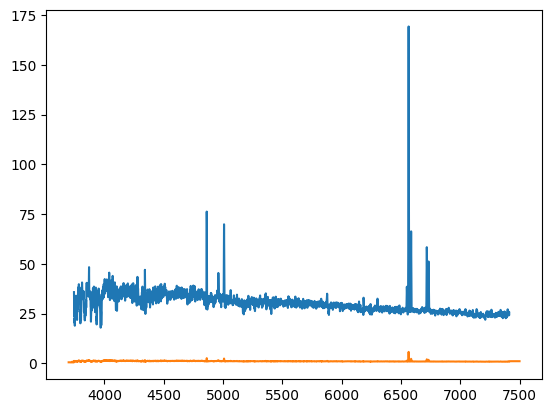

In [45]:
specobjid_1 = sf_03_df.index.to_list()[0]
idx_spec_1 = specobjid_to_idx(specobjid_1, idx_id_bin_03)
spec_1 = spectra[idx_spec_1]
# ------------------------------------------------------------
# non normalized
row = sf_03_df.loc[specobjid_1]
print(
    # f"SpecObjID: {specobjid},"
    f"S/N: {row['snMedian']},"
    f"z: {row['z']},"
    f"subClass: {row['subClass']},"
    f"ebv: {row['ebv']}"        
)

sas_path = meta.get_file_location_sas(row)
spec_1_fits_name = f"{sas_path[1]}.fits"
sdss_sas_link = (
    f"https://data.sdss.org/{sas_path[0]}"
)
print(f"sdss link: {sdss_sas_link}\nfname:{spec_1_fits_name}")

spec_1_location = f'{fits_files_dir}/{spec_1_fits_name}'
(
    raw_flux_1, sky_1,
    raw_wave_1, ivar_1, specobjid_1
) = get_data_from_fits_file(spec_1_location)

ebv_1 = sf_03_df.loc[specobjid_1, 'ebv']

spec_1_dered = OI_noise_dered(
    raw_wave_1, raw_flux_1,
    ivar_1, ebv_1
)

z_1 = sf_03_df.loc[specobjid_1, 'z']
rest_wave_1 = raw_wave_1 / (1 + z_1)

spec_1_common_grid = common_grid_interp(wave_grid, raw_wave_1, spec_1_dered, z_1)
median_flux_1 = np.nanmedian(spec_1_common_grid)
print(median_flux_1)
# convert to nanometers
plt.plot(wave_grid, spec_1_common_grid, wave, spec_1)

S/N: 26.51983,z: 0.03238587,subClass: STARFORMING,ebv: 0.0396599425160176
sdss link: https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1850
fname:spec-1850-53786-0175.fits
N of NaNs before OI interp: 0
N of NaNs before masking: 0
N of NaNs after uncertainty masking: 676
median flux: 36.01468200721465


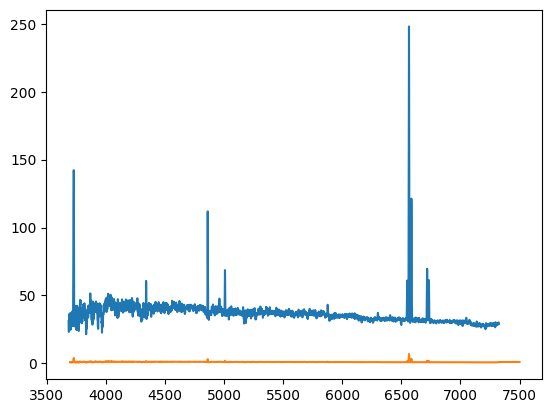

In [46]:
specobjid_2 = sf_03_df.index.to_list()[3]
idx_spec_2 = specobjid_to_idx(specobjid_2, idx_id_bin_03)
spec_2 = spectra[idx_spec_2]
# ------------------------------------------------------------
# non normalized
row = sf_03_df.loc[specobjid_2]
print(
    # f"SpecObjID: {specobjid},"
    f"S/N: {row['snMedian']},"
    f"z: {row['z']},"
    f"subClass: {row['subClass']},"
    f"ebv: {row['ebv']}"        
)

sas_path = meta.get_file_location_sas(row)
spec_2_fits_name = f"{sas_path[1]}.fits"
sdss_sas_link = (
    f"https://data.sdss.org/{sas_path[0]}"
)
print(f"sdss link: {sdss_sas_link}\nfname:{spec_2_fits_name}")

spec_2_location = f'{fits_files_dir}/{spec_2_fits_name}'
(
    raw_flux_2, sky_2,
    raw_wave_2, ivar_2, specobjid_2
) = get_data_from_fits_file(spec_2_location)

ebv_2 = sf_03_df.loc[specobjid_2, 'ebv']

spec_2_dered = OI_noise_dered(
    raw_wave_2, raw_flux_2,
    ivar_2, ebv_2
)

z_2 = sf_03_df.loc[specobjid_2, 'z']
rest_wave_2 = raw_wave_2 / (1 + z_2)

spec_2_common_grid = common_grid_interp(wave_grid, raw_wave_2, spec_2_dered, z_2)
median_flux_2 = np.nanmedian(spec_2_common_grid)
print(f"median flux: {median_flux_2}")
# convert to nanometers
plt.plot(wave_grid, spec_2_common_grid, wave, spec_2)

## Figure

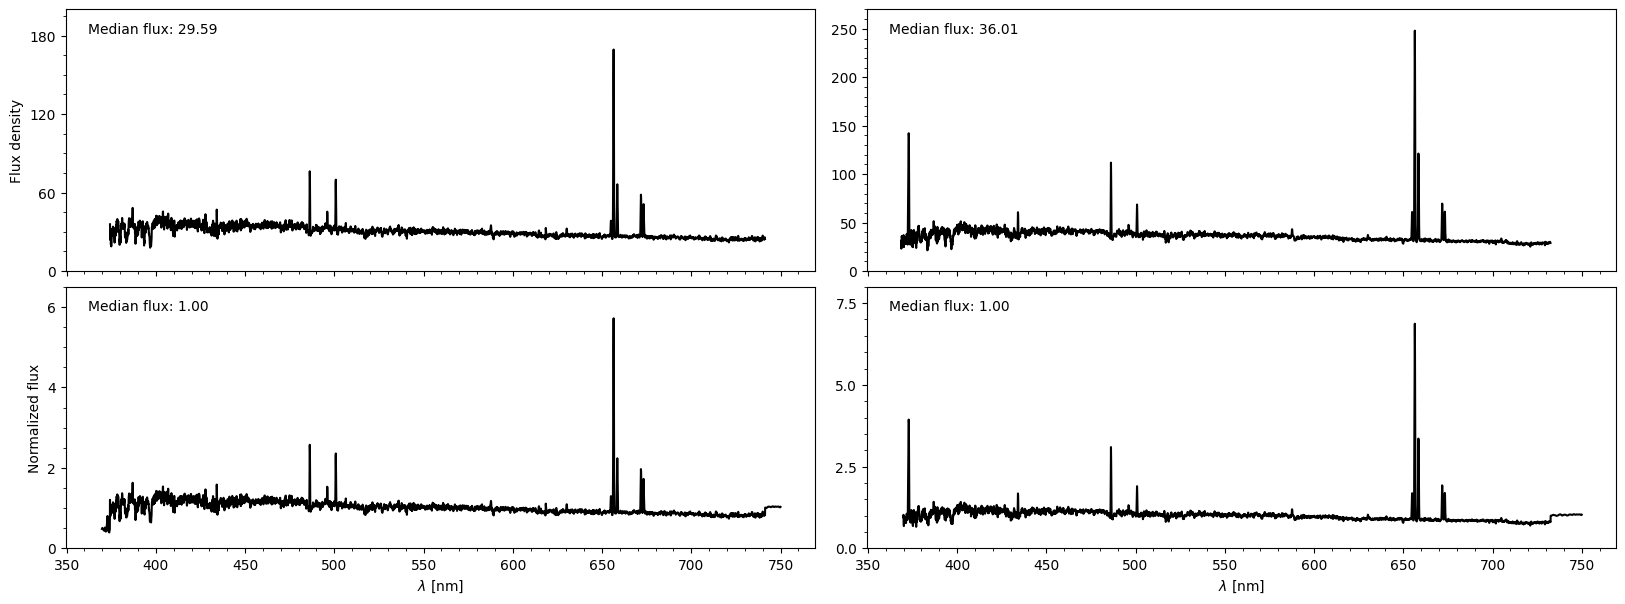

In [47]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 7),
    sharex=True,
)
# -------------------------------------------------
y_label_1 = 'Flux density'
y_label_2 = 'Normalized flux'
wave_grid_nm = wave_grid*0.1
wave_nm = wave*0.1
# -------------------------------------------------
# non mormalized
# Spec 1
axs[0,0].plot(wave_grid_nm, spec_1_common_grid, color='black')
    
axs[0, 0].text(
    0.03, 0.95,
    f'Median flux: {median_flux_1:.2f}', 
    transform=axs[0, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[0, 0].set_ylim(0, 200)
ticks = [0, 60, 120, 180]
axs[0, 0].set_yticks(ticks)

axs[0,0].set_ylabel(y_label_1)
# -------
# spec 2
axs[0, 1].plot(wave_grid_nm, spec_2_common_grid, color='black')
    
axs[0, 1].text(
    0.03, 0.95,
    f'Median flux: {median_flux_2:.2f}', 
    transform=axs[0, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[0, 1].set_ylim(0, 270) 
ticks = [0, 50, 100, 150, 200, 250]
axs[0, 1].set_yticks(ticks)

# axs[0,1].set_ylabel(y_label)

# -------------------------------------------------
#  normalized
# Spec 1
axs[1, 0].plot(wave_nm, spec_1, color='black')
    
axs[1, 0].text(
    0.03, 0.95,
    f'Median flux: 1.00', 
    transform=axs[1, 0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[1,0].set_ylim(0, 6.5) 
ticks = [0, 2, 4, 6]
axs[1,0].set_yticks(ticks)

axs[1, 0].set_ylabel(y_label_2)

# -------
# spec 2
axs[1, 1].plot(wave_nm, spec_2, color='black')
    
axs[1, 1].text(
    0.03, 0.95,
    f'Median flux: 1.00', 
    transform=axs[1, 1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[1,1].set_ylim(0, 8) 
ticks = [0, 2.5 , 5, 7.5]
axs[1,1].set_yticks(ticks)

# -------------------------------------------------
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.07
)
fig.savefig(
    f"{ch_3_dir}/median_normalization.pdf",
    bbox_inches='tight'
)